In [12]:
# Import Libraries

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader
from torch.utils.data import random_split

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tqdm import tqdm

In [ ]:
print("CUDA Available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    try:
        # This will raise an error if cuda (GPU) is blocked
        torch.cuda.init()
    except Exception as e:
        print(f"CUDA Initialization Error: {e}")


CUDA Available: True


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [15]:
# Set Random Seed

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

In [16]:
# Define Image Transformations

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [17]:
# Load Dataset
dataset_path = "/content/drive/MyDrive/PotatoDataset"

dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [18]:
# View Class Names

class_names = dataset.classes

print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [19]:
# Number of Images

print("Total images:", len(dataset))

Total images: 3282


In [20]:
# Class Mapping

print(dataset.class_to_idx)

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}


In [21]:
# Determine Dataset Sizes

# Total number of images
dataset_size = len(dataset)

# Define split sizes
train_size = int(0.70 * dataset_size)
validation_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - validation_size

print(f"Total Images      : {dataset_size}")
print(f"Training Images   : {train_size}")
print(f"Validation Images : {validation_size}")
print(f"Testing Images    : {test_size}")

Total Images      : 3282
Training Images   : 2297
Validation Images : 492
Testing Images    : 493


In [22]:
# Split The Dataset

train_dataset, validation_dataset, test_dataset = random_split(
    dataset,
    [train_size, validation_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [23]:
# Create Data Loaders

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [24]:
# Display Dataset Sizes

print("Training Images   :", len(train_dataset))
print("Validation Images :", len(validation_dataset))
print("Testing Images    :", len(test_dataset))

Training Images   : 2297
Validation Images : 492
Testing Images    : 493


In [25]:
# Inspect One Batch

images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Shape       :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Shape       : torch.Size([32])


In [26]:
# Display Class Name

print("Classes:")
for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

Classes:
0: Potato___Early_blight
1: Potato___Late_blight
2: Potato___healthy


In [27]:
# Function To Display Image

def imshow(image):

    image = image.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = std * image + mean

    image = np.clip(image, 0, 1)

    plt.imshow(image)

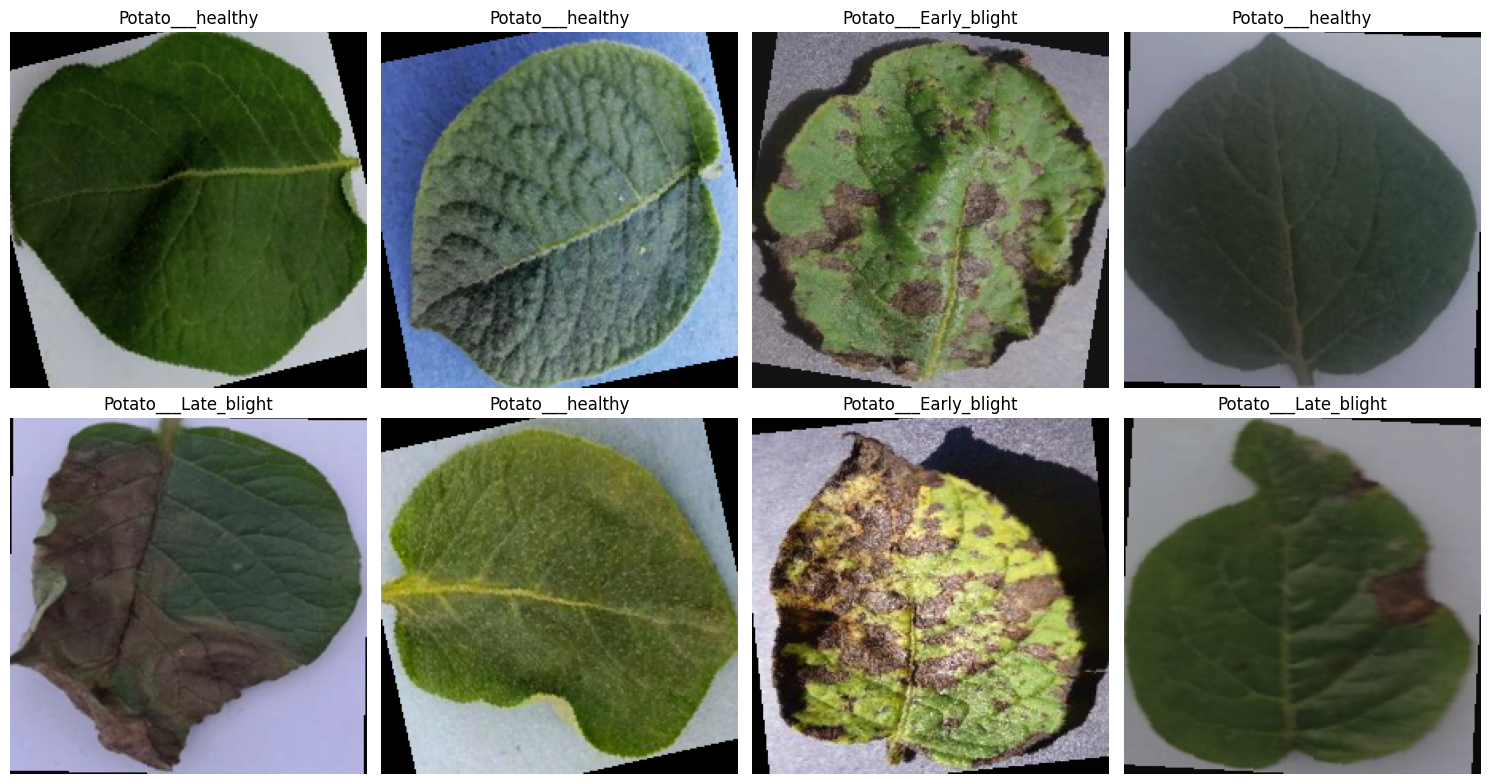

In [28]:
# Display Eight Sample Images

images, labels = next(iter(train_loader))

plt.figure(figsize=(15,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    imshow(images[i])

    plt.title(class_names[labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [29]:
# Count Images Per Class

from collections import Counter

all_labels = [label for _, label in dataset.samples]

label_counts = Counter(all_labels)

print("Images per class:\n")

for label, count in label_counts.items():
    print(f"{class_names[label]} : {count}")

Images per class:

Potato___Early_blight : 1163
Potato___Late_blight : 1151
Potato___healthy : 968


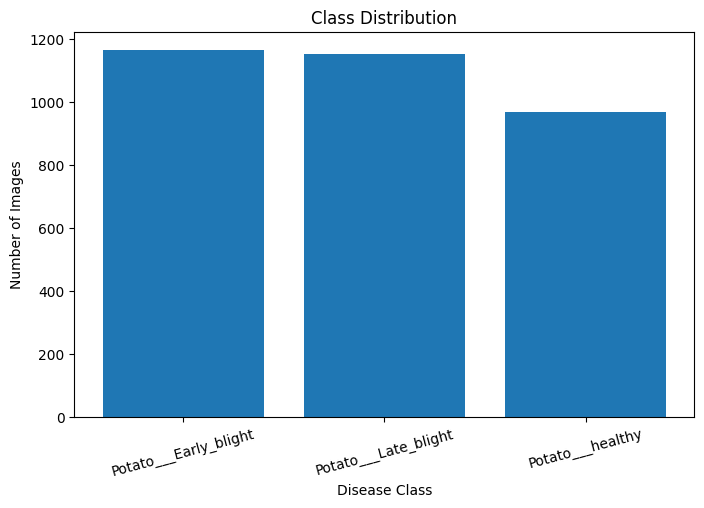

In [30]:
# Visualize The Class Distribution

labels = [class_names[label] for label in label_counts.keys()]
counts = list(label_counts.values())

plt.figure(figsize=(8,5))

plt.bar(labels, counts)

plt.title("Class Distribution")

plt.xlabel("Disease Class")

plt.ylabel("Number of Images")

plt.xticks(rotation=15)

plt.show()

In [31]:
# Build The CNN  Model

class PotatoCNN(nn.Module):

    def __init__(self, num_classes=3):
        super(PotatoCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 512),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, num_classes)

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [32]:
# Create The Model

model = PotatoCNN(num_classes=len(class_names))

print(model)

PotatoCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=3, bias=True)
  )
)


In [33]:
# Move The Model to GPU if available

model = model.to(device)

print("Model moved to:", device)

Model moved to: cuda


In [34]:
# Count Trainable Parameters

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total Parameters      : {total_parameters:,}")
print(f"Trainable Parameters  : {trainable_parameters:,}")

Total Parameters      : 51,475,523
Trainable Parameters  : 51,475,523


In [35]:
criterion = nn.CrossEntropyLoss()

print("Loss Function:", criterion)

Loss Function: CrossEntropyLoss()


In [36]:
# Define The Optimizer

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [37]:
# Learning Rate Scheduler

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=3
)

In [38]:
# Training Function

def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(dataloader)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        progress_bar.set_description(
            f"Loss: {loss.item():.4f}"
        )

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [39]:
# Validation Function

def validate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [40]:
# Prepare For Training

num_epochs = 20

train_losses = []
validation_losses = []

train_accuracies = []
validation_accuracies = []

best_validation_accuracy = 0

In [41]:
# Complete Training Loop

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    validation_loss, validation_accuracy = validate(
        model,
        validation_loader,
        criterion,
        device
    )

    scheduler.step(validation_loss)

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    train_accuracies.append(train_accuracy)
    validation_accuracies.append(validation_accuracy)

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_accuracy:.2f}%")

    print(f"Validation Loss : {validation_loss:.4f}")
    print(f"Validation Accuracy : {validation_accuracy:.2f}%")

    if validation_accuracy > best_validation_accuracy:

        best_validation_accuracy = validation_accuracy

        torch.save(
            model.state_dict(),
            "best_potato_model.pth"
        )

        print("Best model saved!")


Epoch 1/20


Loss: 0.1606: 100%|██████████| 72/72 [08:08<00:00,  6.78s/it]


Train Loss      : 0.8615
Train Accuracy  : 70.27%
Validation Loss : 0.5485
Validation Accuracy : 81.10%
Best model saved!

Epoch 2/20


Loss: 0.4524: 100%|██████████| 72/72 [00:23<00:00,  3.05it/s]


Train Loss      : 0.4297
Train Accuracy  : 83.76%
Validation Loss : 0.4791
Validation Accuracy : 80.69%

Epoch 3/20


...

Train Loss      : 0.1068
Train Accuracy  : 96.34%
Validation Loss : 0.1799
Validation Accuracy : 93.09%

Epoch 19/20


Loss: 0.0485: 100%|██████████| 72/72 [00:23<00:00,  3.08it/s]


Train Loss      : 0.0976
Train Accuracy  : 96.60%
Validation Loss : 0.2842
Validation Accuracy : 93.09%

Epoch 20/20


Loss: 0.1393: 100%|██████████| 72/72 [00:23<00:00,  3.08it/s]


Train Loss      : 0.1017
Train Accuracy  : 96.60%
Validation Loss : 0.2848
Validation Accuracy : 92.28%


In [42]:
# Loading The Best Saved Model

# Load the weights of the best-performing model
model.load_state_dict(torch.load("best_potato_model.pth", map_location=device))

# Move the model to the selected device
model.to(device)

# Set the model to evaluation mode
model.eval()

PotatoCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=3, bias=True)
  )
)

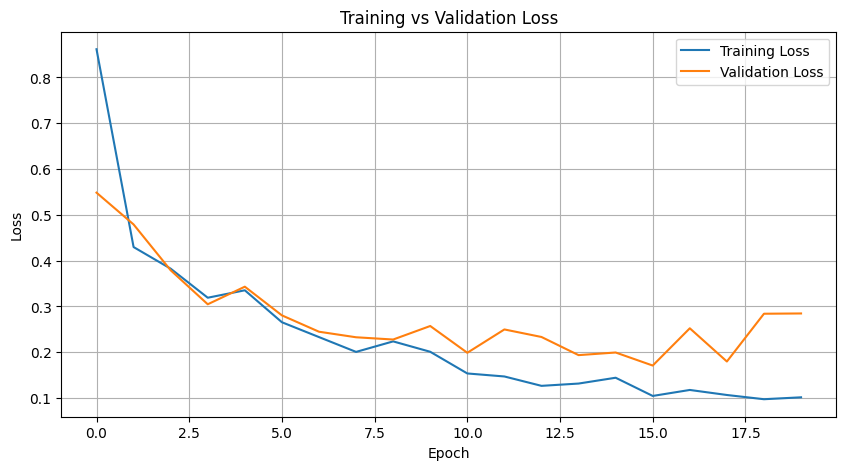

In [43]:
# Plotting The Training And Validation Loss

plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(validation_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

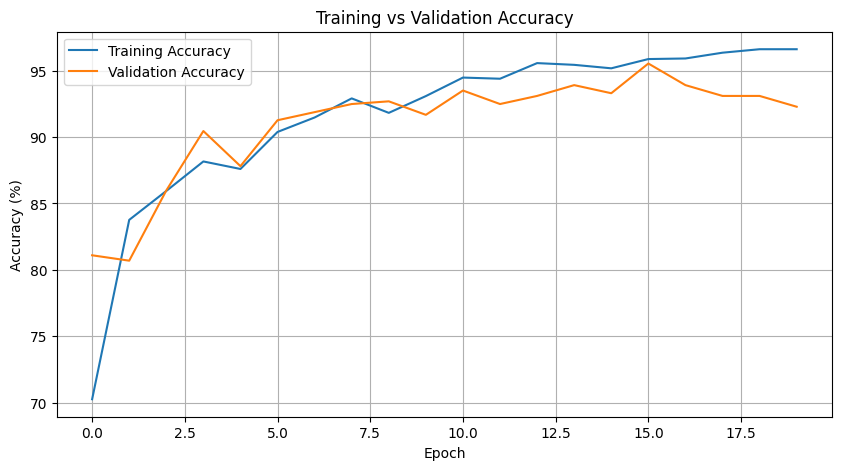

In [44]:
# Plotting The Accuracy Curves

plt.figure(figsize=(10,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(validation_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [61]:
# Evaluate On The Test Set

all_predictions = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 95.33%


In [62]:
# Classification Report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

                       precision    recall  f1-score   support

Potato___Early_blight       0.94      0.98      0.96       163
 Potato___Late_blight       0.97      0.93      0.95       195
     Potato___healthy       0.94      0.96      0.95       135

             accuracy                           0.95       493
            macro avg       0.95      0.95      0.95       493
         weighted avg       0.95      0.95      0.95       493



In [63]:
# Confusion Metrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[159   1   3]
 [  8 182   5]
 [  2   4 129]]


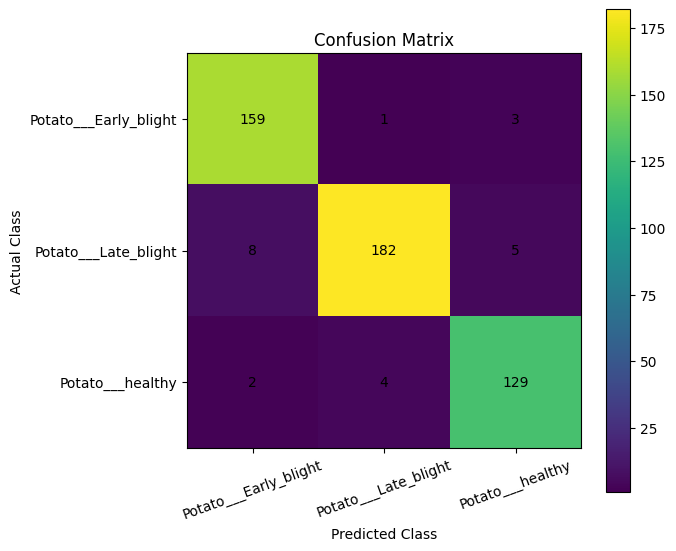

In [64]:
# Visualize The Confusion Matrix

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=20)
plt.yticks(tick_marks, class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")

plt.tight_layout()

plt.show()

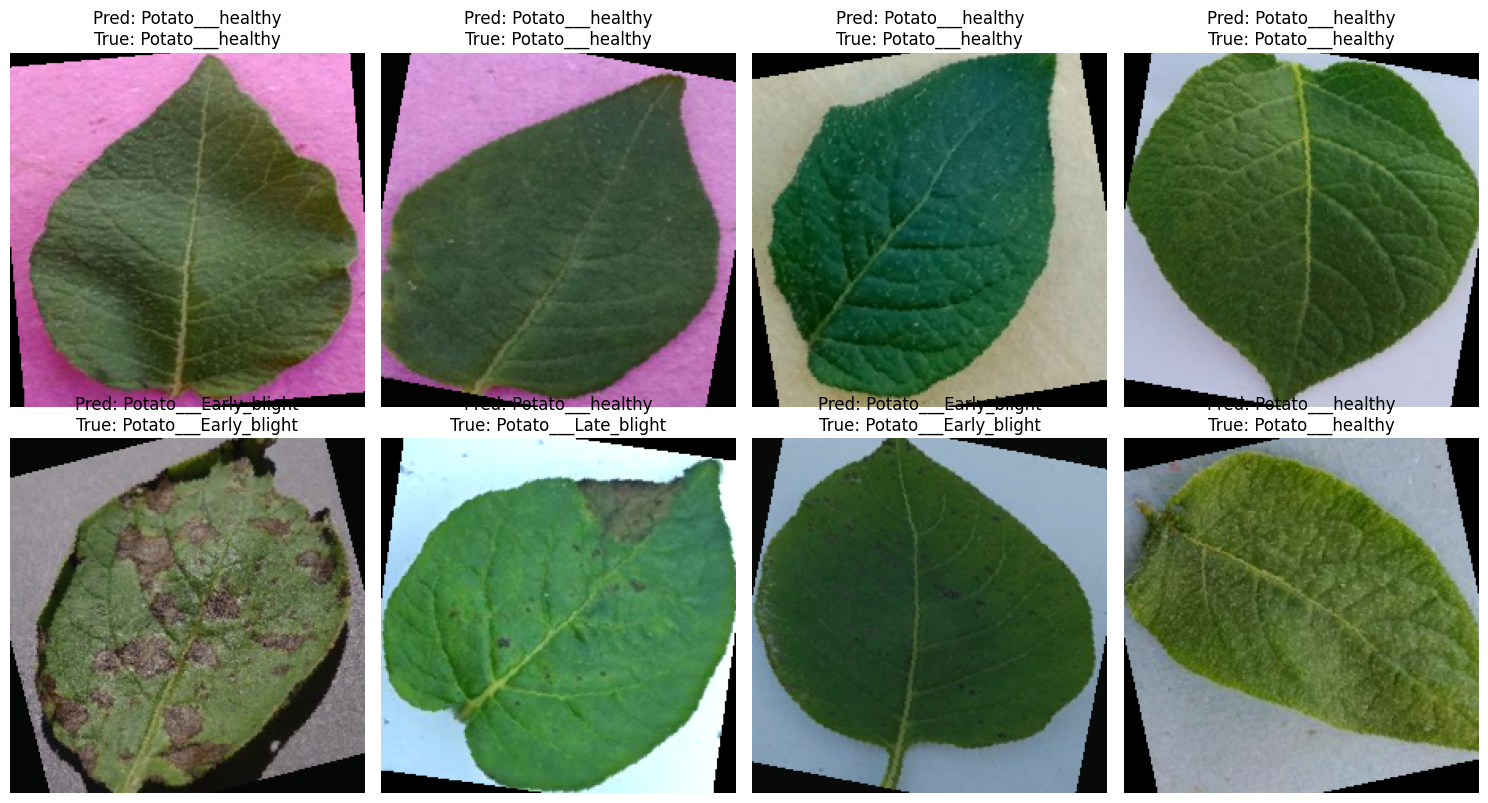

In [65]:
# Display Sample Predictions

images, labels = next(iter(test_loader))

images = images.to(device)

outputs = model(images)

_, predictions = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(15,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    image = images[i].numpy().transpose((1,2,0))

    image = image * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])

    image = np.clip(image,0,1)

    plt.imshow(image)

    plt.title(
        f"Pred: {class_names[predictions[i]]}\nTrue: {class_names[labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()